<a href="https://colab.research.google.com/github/FarrelAD/Intelecta-Cup-Data-Mining-2025/blob/main/notebooks/146-linearreg-intelecta-cup-trainingipynb" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a href="https://www.kaggle.com/kernels/welcome?script=https://github.com/FarrelAD/Intelecta-Cup-Data-Mining-2025/blob/main/notebooks/146-linearreg-intelecta-cup-trainingipynb" target="_blank">
    <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle"/>
</a>

# 0. Preparation

In [1264]:
import os
import sys
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import make_scorer, mean_absolute_percentage_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_percentage_error
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

# Detect environment
def detect_environment():
    """Detect if running in Colab, Kaggle, or local environment"""
    if 'google.colab' in sys.modules:
        return 'colab'
    elif 'kaggle_secrets' in sys.modules or os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
        return 'kaggle'
    else:
        return 'local'

ENV = detect_environment()
print(f"🔍 Detected environment: {ENV.upper()}")

🔍 Detected environment: LOCAL


# 1. Dataset Download and Setup

In [1265]:
def setup_dataset_paths(env: str) -> str:
    if env == 'colab':
        dataset_name = "intelecta-cup-data-mining-competition"
        local_path = "/content/dataset"

        if not os.path.exists(local_path):
            print("📥 Setting up tabular dataset in Colab...")

            kaggle_json_drive = "/content/drive/MyDrive/kaggle.json"
            kaggle_json_local = "/root/.kaggle/kaggle.json"

            if os.path.exists(kaggle_json_drive):
                print("📂 Copying kaggle.json from Drive...")
                !mkdir -p /root/.kaggle
                !cp "{kaggle_json_drive}" "{kaggle_json_local}"
                !chmod 600 "{kaggle_json_local}"
                print("✅ Kaggle credentials loaded from Drive")
            else:
                print("⚠️ Please upload kaggle.json manually or place it in Drive root folder")
                from google.colab import files
                uploaded = files.upload()
                for fn in uploaded.keys():
                    !mkdir -p /root/.kaggle
                    !mv "{fn}" "/root/.kaggle/kaggle.json"
                    !chmod 600 "/root/.kaggle/kaggle.json"
                    print(f"✅ Kaggle credentials uploaded: {fn}")

            # --- Download dataset ---
            !kaggle competitions download -c {dataset_name} -p /content

            import zipfile
            zip_path = f"/content/{dataset_name}.zip"
            if os.path.exists(zip_path):
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(local_path)
                print(f"✅ Dataset extracted to {local_path}")
            else:
                raise FileNotFoundError(f"Dataset zip not found: {zip_path}")

        return {
            'train_csv': f"{local_path}/train.csv",
            'test_csv': f"{local_path}/test.csv",
            'save_dir': "/content/drive/MyDrive/PROJECTS/Cognivio/models"
        }

    elif env == 'kaggle':
        return {
            'train_csv': "/kaggle/input/intelecta-cup-data-mining-competition/train.csv",
            'test_csv': "/kaggle/input/intelecta-cup-data-mining-competition/test.csv",
            'save_dir': "/kaggle/working"
        }

    else:
        base_path = "data"
        return {
            'train_csv': f"{base_path}/train.csv",
            'test_csv': f"{base_path}/test.csv",
            'save_dir': "models"
        }

# Setup paths
paths = setup_dataset_paths(ENV)
print(f"📁 Dataset paths configured for {ENV}:")
for key, path in paths.items():
    exists = "✅" if os.path.exists(path) else "⚠️"
    print(f"   {key}: {path} {exists}")

# Create save directory
os.makedirs(paths['save_dir'], exist_ok=True)

# Set random seed for reproducibility
def set_seed(seed: int = 20) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

📁 Dataset paths configured for local:
   train_csv: data/train.csv ✅
   test_csv: data/test.csv ✅
   save_dir: models ✅


# 3. Dataset Overview

In [1266]:
df = pd.read_csv(paths['train_csv'])

# # Sort data by 'Tahun' to ensure chronological order for downstream steps
# if 'Tahun' in df.columns:
#     df = df.sort_values(by='Tahun', ascending=True).reset_index(drop=True)
#     print("✅ Data sorted by 'Tahun' (ascending)")
# else:
#     print("⚠️ Column 'Tahun' not found; skipping sort")

display(df.head(20))
display(df.describe())
display(df.info())

,ID,Tahun,Nama_Negara,Wilayah,Jenis_Tanaman,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Strategi_Adaptasi,Suhu_Rata_Rata_C
0,0,2015,USA,South,Soybeans,1658.71,13.36,2.620,10,74.41,38.97,2.64,46.07,Manajemen Air,20.43
1,1,2022,China,East,Wheat,1478.74,9.55,0.570,2,36.90,49.99,77.22,88.87,Rotasi Tanaman,-0.33
2,2,2000,India,'West Bengal',Fruits,1252.34,27.37,2.115,3,34.21,2.75,83.94,77.15,Pertanian Organik,12.97
3,3,2008,Nigeria,'North West',Sugarcane,209.89,16.16,4.158,5,91.74,36.80,37.50,73.59,Pertanian Organik,12.81
4,4,1991,Canada,Ontario,Vegetables,1086.67,3.71,2.430,0,14.72,7.22,28.72,41.90,Tanpa Adaptasi,4.22
5,5,1990,Australia,Queensland,Fruits,2265.29,2.33,2.030,4,79.39,48.80,3.30,77.63,Tanpa Adaptasi,14.70
6,6,2017,Russia,Northwestern,Rice,586.35,7.00,1.070,10,88.96,42.20,71.15,45.82,Tanaman Tahan Kekeringan,7.34
7,7,1995,China,Central,Vegetables,2281.25,24.21,2.907,1,27.44,23.94,13.96,50.97,Tanaman Tahan Kekeringan,16.97
8,8,2016,France,'Provence-Alpes-Cote d’Azur',NaN,792.07,10.31,3.420,1,51.51,4.60,75.99,94.94,Pertanian Organik,30.23
9,9,1991,Nigeria,'North West',Cotton,1746.26,25.28,2.772,7,39.09,9.33,90.96,59.65,Manajemen Air,20.30


,ID,Tahun,Total_Curah_Hujan_mm,Emisi_CO2_JT_Ton,Hasil_Panen_Ton_per_HA,Kejadian_Cuaca_Ekstrim,Akses_Irigasi,Penggunaan_Pestisida_KG_per_HA,Penggunaan_Pupuk_KG_per_HA,Indeks_Kesehatan_Tanah,Suhu_Rata_Rata_C
count,8000.00000,8000.000000,7821.000000,8000.000000,7800.000000,8000.000000,7819.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,3999.50000,2007.032750,1615.503060,15.271184,2.238219,4.989750,55.394575,24.920015,49.706654,64.824446,15.206680
std,2309.54541,10.106035,807.932322,8.551214,0.996626,3.171814,26.034847,14.454507,28.674985,20.153617,11.490611
min,0.00000,1990.000000,200.170000,0.500000,0.450000,0.000000,10.010000,0.000000,0.030000,30.000000,-4.990000
25%,1999.75000,1998.000000,929.290000,7.860000,1.449000,2.000000,32.905000,12.550000,25.160000,47.115000,5.377500
50%,3999.50000,2007.000000,1614.790000,15.250000,2.170000,5.000000,55.340000,24.930000,49.270000,64.675000,15.140000
75%,5999.25000,2016.000000,2316.820000,22.820000,2.930000,8.000000,77.770000,37.382500,74.430000,82.302500,25.340000
max,7999.00000,2024.000000,2999.670000,30.000000,5.000000,10.000000,99.990000,49.990000,99.990000,100.000000,35.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              8000 non-null   int64  
 1   Tahun                           8000 non-null   int64  
 2   Nama_Negara                     8000 non-null   object 
 3   Wilayah                         8000 non-null   object 
 4   Jenis_Tanaman                   7781 non-null   object 
 5   Total_Curah_Hujan_mm            7821 non-null   float64
 6   Emisi_CO2_JT_Ton                8000 non-null   float64
 7   Hasil_Panen_Ton_per_HA          7800 non-null   float64
 8   Kejadian_Cuaca_Ekstrim          8000 non-null   int64  
 9   Akses_Irigasi                   7819 non-null   float64
 10  Penggunaan_Pestisida_KG_per_HA  8000 non-null   float64
 11  Penggunaan_Pupuk_KG_per_HA      8000 non-null   float64
 12  Indeks_Kesehatan_Tanah          80

None

In [1267]:
# Check for issues
print("🔍 Data Diagnostics:")
print(f"Target range: {df['Suhu_Rata_Rata_C'].min():.2f} to {df['Suhu_Rata_Rata_C'].max():.2f}")
print(f"Target mean: {df['Suhu_Rata_Rata_C'].mean():.2f}")
print(f"Target std: {df['Suhu_Rata_Rata_C'].std():.2f}")
print(f"\nZero values in target: {(df['Suhu_Rata_Rata_C'] == 0).sum()}")
print(f"Negative values in target: {(df['Suhu_Rata_Rata_C'] < 0).sum()}")
print(f"Missing values in target: {df['Suhu_Rata_Rata_C'].isnull().sum()}")

🔍 Data Diagnostics:
Target range: -4.99 to 35.00
Target mean: 15.21
Target std: 11.49

Zero values in target: 0
Negative values in target: 971
Missing values in target: 0


# 2. Data Preprocessing

In [1268]:
# Handle missing values
numeric_features = ['Total_Curah_Hujan_mm', 'Hasil_Panen_Ton_per_HA', 'Akses_Irigasi']
categorical_features = ['Jenis_Tanaman', 'Nama_Negara', 'Wilayah', 'Strategi_Adaptasi']

# Impute numeric features with median
numeric_imputer = SimpleImputer(strategy='median')
df[numeric_features] = numeric_imputer.fit_transform(df[numeric_features])

# Impute categorical with mode
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_features] = cat_imputer.fit_transform(df[categorical_features])

# Encode categorical variables
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le

# Feature engineering
df['CO2_per_Rainfall'] = df['Emisi_CO2_JT_Ton'] / (df['Total_Curah_Hujan_mm'] + 1)
df['Pesticide_per_Fertilizer'] = df['Penggunaan_Pestisida_KG_per_HA'] / (df['Penggunaan_Pupuk_KG_per_HA'] + 1)
df['Yield_Efficiency'] = df['Hasil_Panen_Ton_per_HA'] * df['Indeks_Kesehatan_Tanah'] / 100

# Prepare features and target
feature_cols = [col for col in df.columns if col not in ['Suhu_Rata_Rata_C', 'ID'] + categorical_features]
X = df[feature_cols]
y = df['Suhu_Rata_Rata_C']

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 4. Model Selection

In [ ]:
# Build Darts TimeSeries from the already preprocessed DataFrame
import os, sys
from pathlib import Path

# Ensure project root (containing the `darts/` package) is on Python path when running from the notebook folder
proj_root = Path.cwd().resolve().parent
if (proj_root / "darts" / "__init__.py").exists():
    sys.path.insert(0, str(proj_root))

from darts import TimeSeries
from darts.models import (
    LightGBMModel,
    RegressionEnsembleModel,
    LinearRegressionModel,
    NaiveDrift,
    NaiveSeasonal,
)
from sklearn.metrics import mean_absolute_percentage_error

# Prepare an explicit integer time axis for robustness
_df_ts = df.copy()
_df_ts["t"] = np.arange(len(_df_ts))

# Target series
series_target = TimeSeries.from_dataframe(
    _df_ts, time_col="t", value_cols=["Suhu_Rata_Rata_C"]
)

# Use engineered numeric columns as past covariates
covar_cols = [c for c in feature_cols if c != "Suhu_Rata_Rata_C"]
series_cov = TimeSeries.from_dataframe(
    _df_ts[["t"] + covar_cols], time_col="t", value_cols=covar_cols
)

# Temporal split that respects order
split_idx = int(len(_df_ts) * 0.8)
split_point = series_target.time_index[split_idx]
series_trg_train, series_trg_val = series_target.split_before(split_point)
series_cov_train, series_cov_val = series_cov.split_before(split_point)

# Simple heuristic to infer a reasonable seasonal period K for NaiveSeasonal using ACF
# Falls back to K=1 (last value) if no strong seasonal signal is detected
def infer_seasonal_period(values, max_k=24, min_k=2, threshold=0.3):
    x = np.asarray(values).reshape(-1)
    if len(x) < (min_k * 3):
        return 1, 0.0
    x = x - x.mean()
    best_k, best_corr = 1, 0.0
    # don't search beyond a third of the series length for stability
    upper = min(max_k, max(min_k, len(x) // 3))
    for k in range(min_k, upper + 1):
        # pearson correlation between series and lagged series
        try:
            corr = np.corrcoef(x[:-k], x[k:])[0, 1]
        except Exception:
            corr = 0.0
        if np.isfinite(corr) and corr > best_corr:
            best_corr = float(corr)
            best_k = int(k)
    if best_corr >= threshold:
        return best_k, best_corr
    return 1, best_corr


K_guess, K_score = infer_seasonal_period(
    _df_ts["Suhu_Rata_Rata_C"].values,
    max_k=min(48, max(3, len(_df_ts) // 2)),
    min_k=2,
    threshold=0.3,
)
print(f"🔎 Inferred seasonal K = {K_guess} (ACF={K_score:.2f})")
K_guess=12


# Define base forecasting models
# 1) LightGBMModel with lags (ensure at least one seasonal cycle if K_guess>1)
lgbm_lags = max(12, int(K_guess))
# lgbm_base = LightGBMModel(
#     lags=lgbm_lags,
#     lags_past_covariates=lgbm_lags,
#     lags_future_covariates=None,
#     output_chunk_length=10,
#     random_state=42,
# )

# 2) LinearRegressionModel over lagged target + past covariates (as a baseline)
linreg_base = LinearRegressionModel(lags=lgbm_lags, lags_past_covariates=lgbm_lags,)

# 3) NaiveDrift (trend baseline)
naive_drift = NaiveDrift()

# 4) NaiveSeasonal (uses inferred K)
naive_seasonal = NaiveSeasonal(K=K_guess)

base_models = [
    # lgbm_base,
    linreg_base,
    naive_drift,
    naive_seasonal
]

# Build RegressionEnsembleModel
# Note: If `regression_model` is None, Darts will use a LinearRegressionModel with lags_future_covariates=[0]
# to learn how to combine base models' predictions.
model_ts = RegressionEnsembleModel(
    forecasting_models=base_models,
    regression_train_n_points=max(12, int(K_guess)),
)

# Fit on training slice
# The ensemble internally trains base models on series[:-n] and trains the meta-regressor on the last n points.
model_ts.fit(
    series=series_trg_train,
    past_covariates=series_cov_train,
    verbose=False,
)

# Predict the length of the validation slice autoregressively
pred_val = model_ts.predict(len(series_trg_val), past_covariates=series_cov)

# Compute MAPE on the validation horizon and log it
mape_ts = (
    mean_absolute_percentage_error(series_trg_val.values(), pred_val.values()) * 100
)
print(f"📈 Darts RegressionEnsembleModel Validation MAPE: {mape_ts:.4f}%")

🔎 Inferred seasonal K = 1 (ACF=0.02)

Some `forecasting_models` in the ensemble do not support past covariates, the past covariates will be provided only to the models supporting them when calling fit()` or `predict()`. To hide these warnings, set `show_warnings=False`.


`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


📈 Darts RegressionEnsembleModel Validation MAPE: 124.7780%


In [1270]:
# Check predictions distribution for either Darts (pred_val) or sklearn (y_pred_val)
print("\n📊 Validation Predictions:")

pred_arr = None
actual_arr = None

# Prefer Darts variables if present
if 'pred_val' in globals() or 'pred_val' in locals():
    try:
        pred_arr = np.asarray(pred_val.values()).reshape(-1)
        actual_arr = np.asarray(series_trg_val.values()).reshape(-1)
    except Exception as e:
        print(f"⚠️ Unable to extract values from Darts TimeSeries: {e}")

# # Fallback to sklearn variables
# if pred_arr is None and (('y_pred_val' in globals()) or ('y_pred_val' in locals())):
#     pred_arr = np.asarray(y_pred_val).reshape(-1)
#     # ensure lengths match in case y_val is longer
#     if 'y_val' in globals() or 'y_val' in locals():
#         actual_arr = np.asarray(y_val.iloc[: len(pred_arr)].values).reshape(-1)

if pred_arr is None or actual_arr is None:
    print("❌ No predictions found. Run either the Darts RegressionEnsembleModel section (producing pred_val) or the sklearn section (producing y_pred_val) first.")
else:
    print(f"Pred range: {pred_arr.min():.2f} to {pred_arr.max():.2f}")
    print(f"Pred mean: {pred_arr.mean():.2f}")
    print(f"Actual range: {actual_arr.min():.2f} to {actual_arr.max():.2f}")
    print(f"Actual mean: {actual_arr.mean():.2f}")

    # Check for near-zero predictions (causes huge MAPE)
    near_zero_mask = np.abs(pred_arr) < 0.1
    print(f"\n⚠️ Predictions near zero: {near_zero_mask.sum()} / {len(pred_arr)}")
    if near_zero_mask.sum() > 0:
        print(f"Actual values for near-zero predictions: {actual_arr[near_zero_mask]}")


📊 Validation Predictions:
Pred range: -7.60 to 8.63
Pred mean: 0.66
Actual range: -4.93 to 35.00
Actual mean: 15.44

⚠️ Predictions near zero: 55 / 1600
Actual values for near-zero predictions: [-3.49 20.68  7.83  1.41 17.13  3.88 26.96  6.36 28.44 17.32 26.15 34.05
 31.08 28.99 25.34 22.02 15.31 21.79 17.07 25.16 14.58 18.05 24.3  32.72
 21.08  8.46  0.5   9.5  15.9  23.73 -0.27 23.18 15.89  1.36 24.76 12.4
 25.43 13.31 12.05 -2.32 32.53 -3.19 -0.06 11.23 26.48  2.71 32.69 34.09
 29.05  1.83  9.48  5.5  26.93 -0.86 34.59]


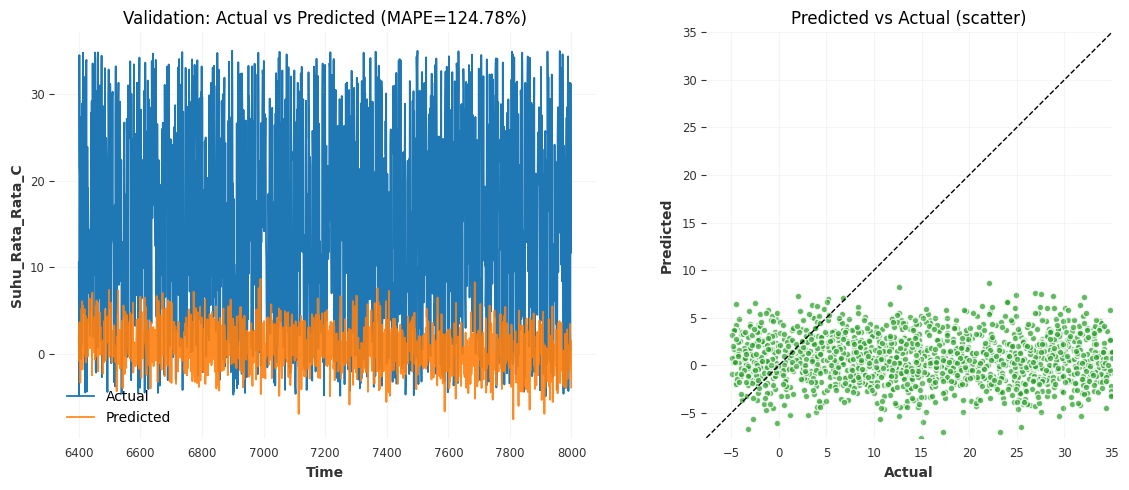

In [1271]:
# Plot Actual vs Predicted (validation)
import numpy as np
import matplotlib.pyplot as plt

# Ensure pred_arr and actual_arr are available; otherwise derive from Darts variables
try:
    pred_arr  # type: ignore[name-defined]
    actual_arr  # type: ignore[name-defined]
except NameError:
    pred_arr = None
    actual_arr = None

if pred_arr is None or actual_arr is None:
    try:
        pred_arr = np.asarray(pred_val.values()).reshape(-1)
        actual_arr = np.asarray(series_trg_val.values()).reshape(-1)
    except Exception as e:
        print("❌ No predictions to plot. Run the validation prediction cell first.")
        raise

# Align lengths defensively
n = min(len(pred_arr), len(actual_arr))
pred_arr = pred_arr[:n]
actual_arr = actual_arr[:n]

# Build time axis if available
try:
    t_index = np.asarray(series_trg_val.time_index)[:n]
except Exception:
    t_index = np.arange(n)

# Metric helper (robust MAPE)
def _safe_mape(y_true, y_pred):
    eps = 1e-9
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100.0)

mape_plot = _safe_mape(actual_arr, pred_arr)

# Create figure with two views: series-over-time and scatter vs y=x
plt.figure(figsize=(12, 5))

ax1 = plt.subplot(1, 2, 1)
ax1.plot(t_index, actual_arr, label="Actual", color="#1f77b4")
ax1.plot(t_index, pred_arr, label="Predicted", color="#ff7f0e", alpha=0.9)
ax1.set_title(f"Validation: Actual vs Predicted (MAPE={mape_plot:.2f}%)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Suhu_Rata_Rata_C")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2 = plt.subplot(1, 2, 2)
ax2.scatter(actual_arr, pred_arr, s=22, alpha=0.75, color="#2ca02c", edgecolor="white")
lims = [min(float(np.min(actual_arr)), float(np.min(pred_arr))),
        max(float(np.max(actual_arr)), float(np.max(pred_arr)))]
ax2.plot(lims, lims, 'k--', linewidth=1)
ax2.set_xlim(lims)
ax2.set_ylim(lims)
ax2.set_aspect('equal', 'box')
ax2.set_title("Predicted vs Actual (scatter)")
ax2.set_xlabel("Actual")
ax2.set_ylabel("Predicted")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Hyperparameter Tuning

# 6. Generate Predictions

In [1272]:
# Load test data
df_test = pd.read_csv(paths['test_csv'])

# Apply same preprocessing
df_test[numeric_features] = numeric_imputer.transform(df_test[numeric_features])
df_test[categorical_features] = cat_imputer.transform(df_test[categorical_features])

for col in categorical_features:
    df_test[f'{col}_encoded'] = label_encoders[col].transform(df_test[col])

# Feature engineering on test
df_test['CO2_per_Rainfall'] = df_test['Emisi_CO2_JT_Ton'] / (df_test['Total_Curah_Hujan_mm'] + 1)
df_test['Pesticide_per_Fertilizer'] = df_test['Penggunaan_Pestisida_KG_per_HA'] / (df_test['Penggunaan_Pupuk_KG_per_HA'] + 1)
df_test['Yield_Efficiency'] = df_test['Hasil_Panen_Ton_per_HA'] * df_test['Indeks_Kesehatan_Tanah'] / 100

X_test = df_test[feature_cols]
X_test_scaled = scaler.transform(X_test)  # kept in case you also run the sklearn path

# --- Darts prediction path ---
# Build a future time index for test and extend covariates into the future so models with lags_past_covariates can predict autoregressively
try:
    # Ensure we have the training _df_ts and covar_cols from the Darts section
    if '_df_ts' not in globals() and '_df_ts' not in locals():
        raise RuntimeError("Darts training variables not found. Run the Darts training cell first.")

    # Create future time index continuing after the last training step
    df_test_ts = df_test.copy()
    start_t = int(_df_ts['t'].iloc[-1]) + 1 if 't' in _df_ts.columns else len(_df_ts)
    df_test_ts['t'] = np.arange(start_t, start_t + len(df_test))

    # Build future covariates TimeSeries and append to training covariates
    covar_cols = [c for c in feature_cols if c != 'Suhu_Rata_Rata_C']
    series_cov_future = TimeSeries.from_dataframe(df_test_ts[['t'] + covar_cols], time_col='t', value_cols=covar_cols)
    series_cov_full = series_cov.append(series_cov_future)

    # Predict n steps equal to test length using the SAME training target series used at fit to ensure aligned time axis
    n_test = len(df_test)
    pred_test_ts = model_ts.predict(n_test, series=series_trg_train, past_covariates=series_cov_full)
    predictions = pred_test_ts.values().reshape(-1)
except Exception as e:
    # Fallback or explicit error to guide the user
    raise RuntimeError(f"Failed to generate Darts predictions. Ensure the Darts training cell ran successfully. Details: {e}")

# Save submission
submission = pd.DataFrame({
    'ID': df_test['ID'],
    'Suhu_Rata_Rata_C': predictions
})
submission_path = f"{paths['save_dir']}/submission.csv"
submission.to_csv(submission_path, index=False)
print(f"✅ Submission saved to {submission_path}")

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


✅ Submission saved to models/submission.csv
